# Ejercicio 8. Incorporación de datos de 2025 y análisis completo

El sistema incorpora 2025 y los indicadores del ejercicio 7 se recalculan con los tres años.

In [1]:
import os
import time
from pathlib import Path

import duckdb
import pandas as pd

if Path.cwd().name == "notebooks":
    os.chdir("..")

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
con = duckdb.connect()


def consulta(ruta):
    """Imprime un archivo de sql, lo ejecuta y muestra el tiempo"""
    texto = Path("sql", ruta).read_text(encoding="utf-8")
    print(texto)
    inicio = time.perf_counter()
    resultado = con.execute(texto).df()
    print(f"-- {time.perf_counter() - inicio:.2f} s")
    return resultado

import subprocess
import sys

con.execute(Path("sql/vistas.sql").read_text(encoding="utf-8"))

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

COLOR = {"yellow": "#eda100", "green": "#008300"}
NOMBRE = {"yellow": "Amarillo", "green": "Verde"}
COLOR_ANIO = {2024: "#2a78d6", 2025: "#eb6834", 2026: "#1baf7a"}
MESES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e", "axes.titlecolor": "#0b0b0b",
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "legend.frameon": False, "legend.fontsize": 9, "figure.dpi": 110, "font.size": 10,
})
miles = FuncFormatter(lambda x, _: f"{x:,.0f}")

def grafica_indicador(datos, titulo, unidad):
    """Dos paneles, amarillo y verde, con una línea por año"""
    fig, ejes = plt.subplots(1, 2, figsize=(10, 3.2))
    for eje, taxi in zip(ejes, ["yellow", "green"]):
        d = datos[datos.taxi == taxi]
        for anio, g in d.groupby(d.periodo.dt.year):
            eje.plot(g.periodo.dt.month, g.valor, color=COLOR_ANIO[anio], label=str(anio), marker="o", markersize=5,
                     markeredgecolor="#fcfcfb", markeredgewidth=1.5)
        eje.set_title(f"Taxi {NOMBRE[taxi].lower()}")
        eje.set_xticks(range(1, 13), MESES)
        eje.set_ylim(0, d.valor.max() * 1.15)
        eje.yaxis.set_major_formatter(miles if d.valor.max() >= 1000 else FuncFormatter(lambda x, _: f"{x:g}"))
    ejes[0].set_ylabel(unidad)
    ejes[0].legend(loc="lower left", ncols=3)
    fig.suptitle(titulo, x=0.01, ha="left", fontweight="bold")
    fig.tight_layout()
    plt.show()


def indicador(archivo, titulo, unidad, mostrar_sql=True):
    ruta = f"indicadores/{archivo}"
    datos = consulta(ruta) if mostrar_sql else con.execute(Path("sql", ruta).read_text(encoding="utf-8")).df()
    datos["periodo"] = pd.to_datetime(datos.periodo)
    tabla = datos.pivot_table(index=datos.periodo.dt.month.rename("mes"),
                              columns=["taxi", datos.periodo.dt.year.rename("anio")], values="valor")
    display(tabla.reindex(columns=["yellow", "green"], level=0))
    grafica_indicador(datos, titulo, unidad)
    return datos

## 8.1 y 8.2 Descarga de 2025

En scripts/download_data.py la lista ANIOS pasa de (2024, 2026) a (2024, 2025, 2026). No hay otro cambio, porque verificar_descarga.py toma la misma lista.

La salida de la descarga está en docs/evidencias/08_descarga_2025.txt.

| Estado | Archivos | Detalle |
| --- | --- | --- |
| Descargados | 24 | Los 12 meses de 2025 de cada tipo |
| Ya existían | 41 | 2024, 2026 y el catálogo de zonas |
| No publicados | 8 | Septiembre a diciembre de 2026 |
| Fallidos | 0 | |

Ningún archivo de 2024 o 2026 se descargó otra vez. La celda siguiente repite la descarga y la verificación contra la lista de la TLC.

In [2]:
salida = subprocess.run([sys.executable, "scripts/download_data.py"], capture_output=True, text=True).stdout
print(salida[salida.index("RESUMEN"):])
salida = subprocess.run([sys.executable, "scripts/verificar_descarga.py"], capture_output=True, text=True).stdout
print(salida.splitlines()[-1])

RESUMEN
  descargados   : 0
  ya existian   : 65
  no publicados : 8
      yellow 2026-09, yellow 2026-10, yellow 2026-11, yellow 2026-12, green 2026-09, green 2026-10, green 2026-11, green 2026-12
  fallidos      : 0



64 de 64 archivos publicados completos. Detalle en docs/verificacion_descarga.csv


In [3]:
consulta("ej5/01_archivos_por_anio.sql")

-- Archivos, meses y registros por tipo de taxi y año, según el pie de cada Parquet
SELECT
    regexp_extract(file_name, '(yellow|green)_tripdata', 1) AS tipo,
    regexp_extract(file_name, '_(\d{4})-\d{2}\.parquet', 1)::INT AS anio,
    count(*) AS archivos,
    min(regexp_extract(file_name, '(\d{4}-\d{2})\.parquet', 1)) AS primer_mes,
    max(regexp_extract(file_name, '(\d{4}-\d{2})\.parquet', 1)) AS ultimo_mes,
    sum(num_rows)::BIGINT AS registros
FROM parquet_file_metadata('data/raw/*/*/*.parquet')
GROUP BY tipo, anio
ORDER BY tipo DESC, anio

-- 0.01 s


,tipo,anio,archivos,primer_mes,ultimo_mes,registros
0,yellow,2024,12,2024-01,2024-12,41169720
1,yellow,2025,12,2025-01,2025-12,48722602
2,yellow,2026,8,2026-01,2026-08,29703355
3,green,2024,12,2024-01,2024-12,660218
4,green,2025,12,2025-01,2025-12,591375
5,green,2026,8,2026-01,2026-08,337114


2025 llega completo, con 12 archivos por tipo, 48,722,602 viajes amarillos y 591,375 verdes. Con los tres años, data/raw tiene 64 archivos y 121,184,384 registros.

## 8.3 Consultas anteriores sobre los tres años

Se ejecutan sin cambios todas las consultas de sql, que incluyen las de los ejercicios 3, 4 y 5, las del benchmark, las de los indicadores y las de este ejercicio.

In [4]:
filas = []
for ruta in sorted(Path("sql").glob("*/*.sql")):
    inicio = time.perf_counter()
    try:
        resultado = con.execute(ruta.read_text(encoding="utf-8")).df()
        estado, n = "ok", len(resultado)
    except duckdb.Error as error:
        estado, n = str(error).splitlines()[0], None
    filas.append({"consulta": ruta.relative_to("sql").as_posix(), "estado": estado, "filas": n,
                  "segundos": round(time.perf_counter() - inicio, 2)})
revision = pd.DataFrame(filas)
print(revision.estado.value_counts().to_string())
revision

estado
ok    44


,consulta,estado,filas,segundos
0,benchmark/01_conteo.sql,ok,2,0.04
1,benchmark/02_un_dia.sql,ok,2,0.14
2,benchmark/03_percentiles_total.sql,ok,2,29.16
3,ej3/01_archivos.sql,ok,2,0.05
4,ej3/02_registros.sql,ok,3,0.04
5,ej3/03_columnas.sql,ok,25,0.02
6,ej3/04_esquema_por_archivo.sql,ok,4,0.03
7,ej3/05_union_by_name.sql,ok,2,0.01
8,ej3/06_muestra_yellow.sql,ok,25,10.36
9,ej3/07_muestra_green.sql,ok,38,0.20


Las 44 consultas terminan sin error sobre los tres años y ninguna necesitó cambios. Las más lentas son los cuartiles exactos del benchmark, con 29 segundos, los percentiles del ejercicio 4, con 24, y el SUMMARIZE de los viajes amarillos, con 21, porque recorren todos los valores de más de 110 millones de viajes. Las demás tardan menos de 11 segundos.

## 8.4 Indicadores con los tres años

Son las mismas consultas de sql/indicadores del ejercicio 7, ahora con 2025.

### I1 Viajes por día

taxi    yellow                       green                
anio      2024      2025      2026    2024    2025    2026
mes                                                       
1      92478.0  104855.0  113401.0  1713.0  1455.0  1244.0
2      99959.0  118020.0  114619.0  1733.0  1546.0  1271.0
3     110873.0  123386.0  121346.0  1739.0  1534.0  1365.0
4     113711.0  122330.0  122437.0  1759.0  1601.0  1405.0
5     116606.0  131952.0  126158.0  1848.0  1661.0  1382.0
6     114179.0  128911.0  121515.0  1716.0  1550.0  1407.0
7      95842.0  112679.0  107907.0  1558.0  1486.0  1264.0
8      92403.0  102553.0  102022.0  1562.0  1426.0  1243.0
9     116040.0  127876.0       NaN  1701.0  1565.0     NaN
10    118681.0  127162.0       NaN  1709.0  1525.0     NaN
11    116906.0  121409.0       NaN  1630.0  1496.0     NaN
12    113422.0  130570.0       NaN  1626.0  1485.0     NaN

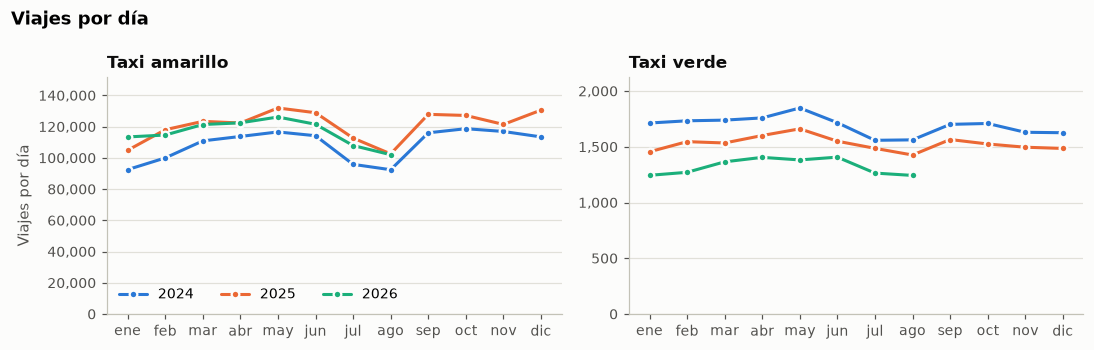

In [5]:
i1 = indicador("01_viajes_por_dia.sql", "Viajes por día", "Viajes por día", mostrar_sql=False)

### I2 Total del viaje mediano

taxi yellow                green              
anio   2024   2025   2026   2024   2025   2026
mes                                           
1     20.16  20.35  23.10  18.34  18.50  20.10
2     20.41  20.70  24.00  18.40  18.80  20.12
3     20.64  21.42  23.35  18.48  19.34  20.46
4     21.00  21.59  23.58  18.85  19.85  20.46
5     21.60  22.35  23.93  19.80  20.25  20.81
6     21.35  22.60  23.84  19.65  20.46  20.95
7     21.00  22.25  23.58  19.53  20.41  20.70
8     21.00  21.80  23.55  19.85  21.00  20.90
9     21.84  23.00    NaN  20.30  21.30    NaN
10    21.84  22.45    NaN  19.75  20.85    NaN
11    21.36  21.90    NaN  19.32  20.41    NaN
12    21.85  24.45    NaN  19.15  20.04    NaN

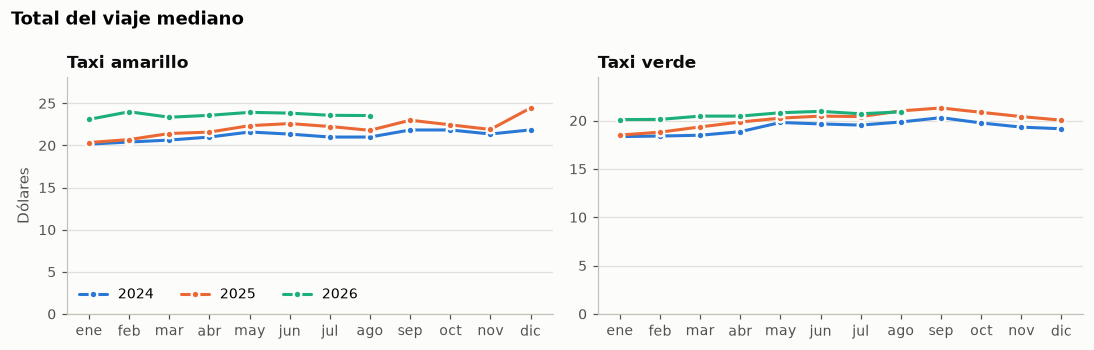

In [6]:
i2 = indicador("02_total_mediano.sql", "Total del viaje mediano", "Dólares", mostrar_sql=False)

### I3 Viajes Flex Fare

taxi yellow             green            
anio   2024  2025  2026  2024  2025  2026
mes                                      
1       4.0  12.7  28.3   6.1   3.9  13.7
2       5.1  19.0  28.9   5.6   4.7  14.7
3      10.6  19.0  22.9   3.8   5.9  15.5
4      11.4  16.1  20.2   3.7   5.2  14.7
5      10.7  21.4  22.5   3.2   5.1  12.9
6      11.3  24.2  25.3   3.5   6.7  15.0
7       8.9  22.9  26.2   3.2  10.8  15.7
8       8.3  20.5  26.5   3.2  10.5  15.5
9      12.4  21.6   NaN   3.2  11.3   NaN
10      9.4  17.3   NaN   3.0  10.4   NaN
11      9.6  17.1   NaN   3.1  12.1   NaN
12      8.2  26.8   NaN   3.8  12.3   NaN

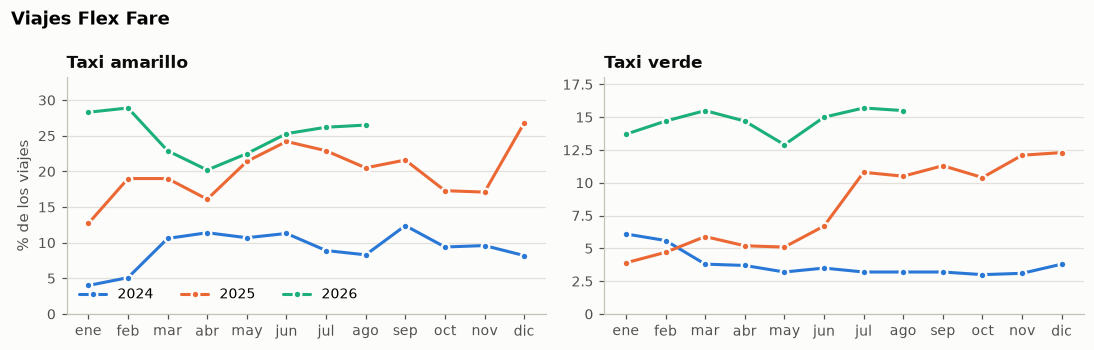

In [7]:
i3 = indicador("03_flex_fare.sql", "Viajes Flex Fare", "% de los viajes", mostrar_sql=False)

### I4 Viajes pagados en efectivo

taxi yellow            green            
anio   2024  2025 2026  2024  2025  2026
mes                                     
1      14.7  11.3  8.3  28.6  24.3  20.6
2      13.7   9.6  8.0  28.0  23.4  20.0
3      13.3   9.9  8.9  29.6  24.3  19.3
4      13.2  10.4  9.3  27.1  23.3  19.0
5      13.3   9.4  9.0  27.2  22.5  19.7
6      13.1   9.1  9.3  27.0  23.0  19.0
7      14.6  10.0  9.8  27.3  22.3  18.2
8      14.9  10.6  9.9  27.1  22.7  19.6
9      12.1   8.8  NaN  26.0  20.6   NaN
10     12.3   9.3  NaN  25.7  20.2   NaN
11     12.1   9.5  NaN  25.3  19.9   NaN
12     13.2   9.2  NaN  25.6  21.1   NaN

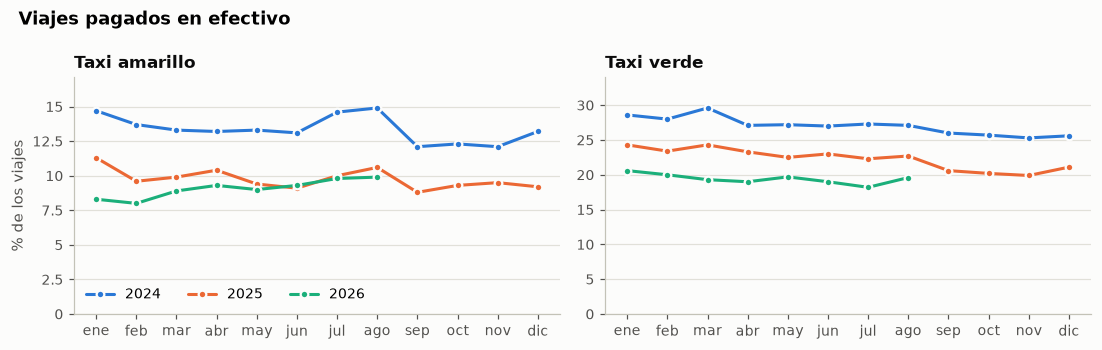

In [8]:
i4 = indicador("04_efectivo.sql", "Viajes pagados en efectivo", "% de los viajes", mostrar_sql=False)

### I5 Propina con tarjeta

taxi yellow             green            
anio   2024  2025  2026  2024  2025  2026
mes                                      
1      26.3  26.3  25.0  22.8  22.9  23.1
2      25.4  26.4  24.8  22.5  22.5  23.0
3      25.2  26.1  24.8  22.4  22.4  23.1
4      25.5  25.9  25.0  22.5  22.4  23.3
5      24.9  25.4  24.5  22.3  22.3  22.7
6      24.7  25.3  26.4  22.1  22.4  22.6
7      25.1  25.1  25.2  22.4  22.4  23.0
8      24.7  25.0  25.0  22.2  21.9  23.0
9      24.4  25.8   NaN  22.1  22.1   NaN
10     24.7  24.9   NaN  22.2  22.5   NaN
11     26.3  24.7   NaN  22.4  22.6   NaN
12     24.9  24.8   NaN  22.6  23.4   NaN

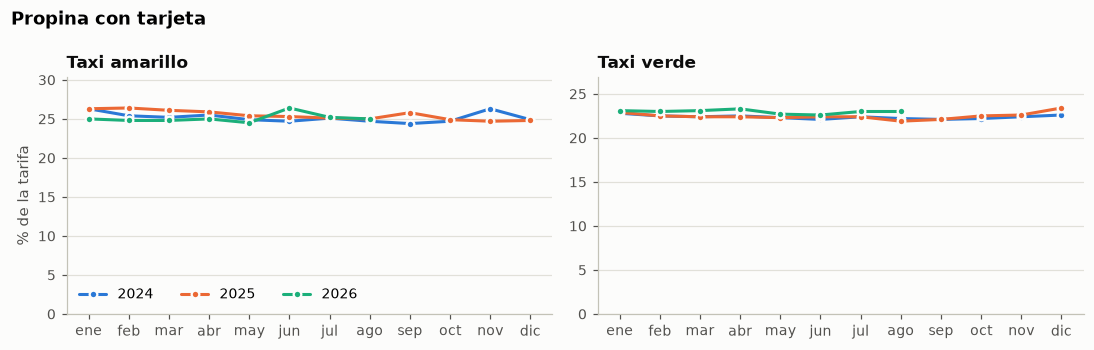

In [9]:
i5 = indicador("05_propina_tarjeta.sql", "Propina con tarjeta", "% de la tarifa", mostrar_sql=False)

### I6 Viajes con cargo CBD

taxi yellow             green           
anio   2024  2025  2026  2024  2025 2026
mes                                     
1       0.0  65.8  70.9   0.0   7.2  7.9
2       0.0  74.1  71.0   0.0   8.8  7.1
3       0.0  74.3  71.5   0.0  10.0  8.1
4       0.0  74.0  71.8   0.0  10.4  8.4
5       0.0  73.3  66.8   0.0  10.6  8.9
6       0.0  73.7  74.2   0.0  10.4  8.5
7       0.0  74.4  77.2   0.0  10.0  9.2
8       0.0  73.7  77.1   0.0  10.8  9.8
9       0.0  73.9   NaN   0.0  10.1  NaN
10      0.0  73.6   NaN   0.0   9.7  NaN
11      0.0  72.8   NaN   0.0   8.9  NaN
12      0.0  72.1   NaN   0.0   8.4  NaN

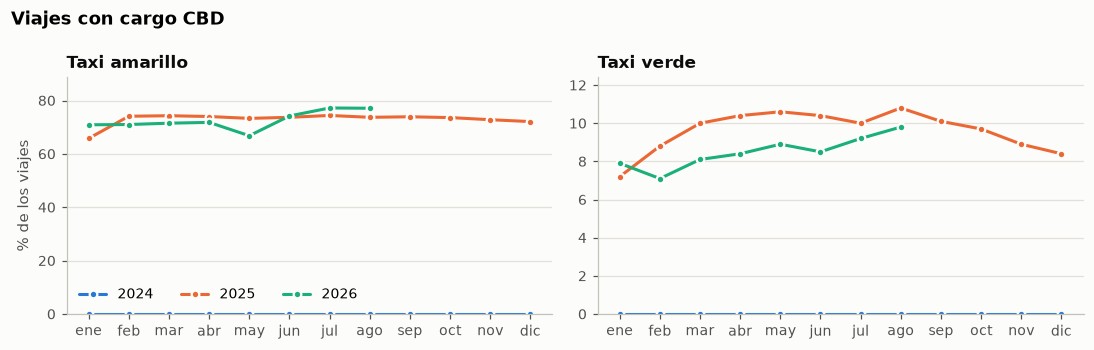

In [10]:
i6 = indicador("06_cargo_cbd.sql", "Viajes con cargo CBD", "% de los viajes", mostrar_sql=False)

### I7 Velocidad dentro de Manhattan

taxi yellow              green              
anio   2024  2025  2026   2024   2025   2026
mes                                         
1      9.05  9.04  8.69  10.18  10.19   9.47
2      8.89  8.89  8.24  10.20  10.05   9.10
3      8.96  9.06  8.74  10.12  10.01   9.85
4      8.81  8.73  8.34  10.10   9.75   9.85
5      8.48  8.53  8.21   9.69   9.46   9.52
6      8.75  8.93  8.37   9.99   9.80   9.57
7      8.91  8.94  8.66  10.45  10.03  10.09
8      8.93  9.21  8.88  10.44  10.14  10.12
9      8.28  8.34   NaN   9.74   9.54    NaN
10     8.12  8.09   NaN   9.81   9.52    NaN
11     8.18  8.14   NaN   9.78   9.84    NaN
12     7.95  8.14   NaN   9.98   9.66    NaN

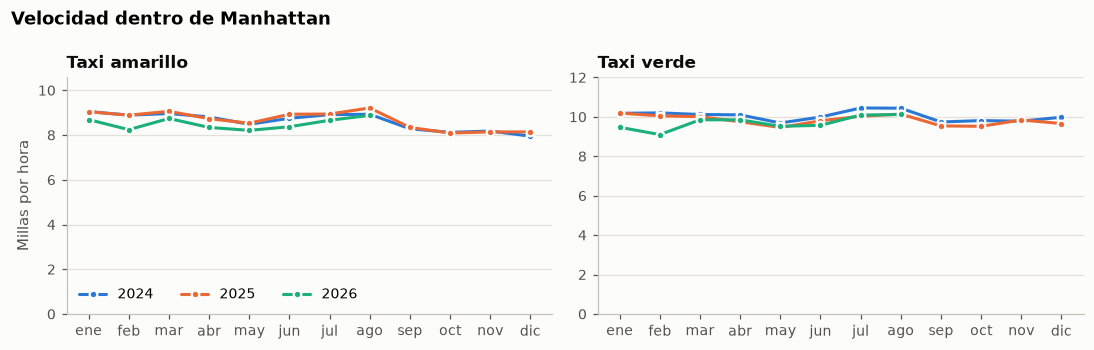

In [11]:
i7 = indicador("07_velocidad_manhattan.sql", "Velocidad dentro de Manhattan", "Millas por hora", mostrar_sql=False)

### I8 Viajes de aeropuerto

taxi yellow            green          
anio   2024  2025 2026  2024 2025 2026
mes                                   
1       9.8   8.5  7.7   3.2  3.1  2.8
2       9.1   7.5  7.3   3.5  3.1  3.1
3       9.5   8.5  8.0   4.0  3.6  3.4
4       9.7   8.7  8.1   4.2  3.7  3.2
5      10.2   9.3  8.0   4.8  4.1  3.7
6      10.0   9.1  8.4   4.3  4.0  3.5
7      11.3   9.3  8.7   4.3  3.5  3.5
8      11.8  10.2  9.2   5.0  4.1  3.6
9      10.4   8.9  NaN   4.8  4.2  NaN
10     10.4   9.3  NaN   4.5  4.1  NaN
11      9.4   8.9  NaN   4.1  3.6  NaN
12      9.8   8.1  NaN   3.9  3.5  NaN

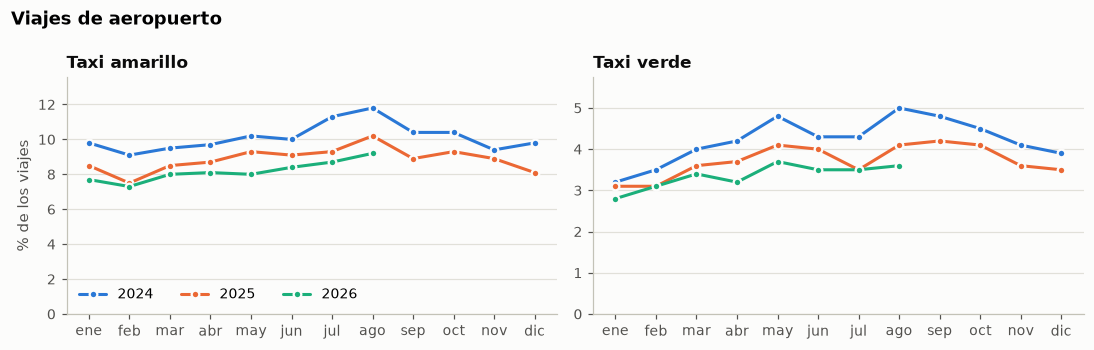

In [12]:
i8 = indicador("08_aeropuertos.sql", "Viajes de aeropuerto", "% de los viajes", mostrar_sql=False)

### I9 Registros excluidos por calidad

taxi yellow              green            
anio   2024   2025  2026  2024  2025  2026
mes                                       
1      3.30   6.47  5.62  6.07  6.66  4.24
2      3.61   7.63  5.60  6.22  7.12  4.80
3      4.06   7.73  4.83  6.16  7.72  4.28
4      2.93   7.57  4.13  6.55  7.85  4.73
5      2.93  10.92  4.40  6.11  7.05  4.66
6      3.22  10.54  5.00  5.95  5.84  4.40
7      3.44  10.41  5.24  6.81  4.44  4.98
8      3.85  11.05  5.22  6.48  4.52  5.26
9      4.18   9.76   NaN  6.24  3.96   NaN
10     4.03  10.99   NaN  5.64  4.30   NaN
11     3.82  12.89   NaN  6.36  4.30   NaN
12     4.15   5.98   NaN  6.63  4.54   NaN

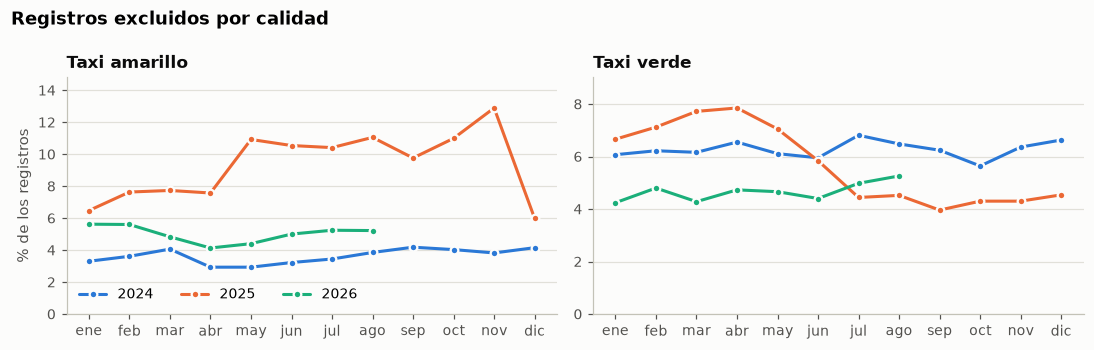

In [13]:
i9 = indicador("09_registros_excluidos.sql", "Registros excluidos por calidad", "% de los registros", mostrar_sql=False)

Al ejecutar otra vez scripts/tablero_metabase.py, el tablero de Metabase toma los tres años sin cambios en el código, porque las consultas leen las mismas vistas.

![Tablero con 2024, 2025 y 2026](../docs/evidencias/08_tablero_2024_2025_2026.png)

## 8.5 Evolución de los indicadores

Para comparar años con los mismos meses, la consulta resume enero a agosto, los meses disponibles en 2026.

In [14]:
resumen = consulta("ej8/01_enero_a_agosto.sql")
resumen.set_index(["taxi", "anio"]).T

-- Indicadores de enero a agosto de cada año, los meses disponibles en los tres años
WITH base AS (
    SELECT
        v.*,
        inicio.distrito = 'Manhattan' AND fin.distrito = 'Manhattan' AS dentro_de_manhattan
    FROM viajes_validos AS v
    JOIN zonas AS inicio ON v.PULocationID = inicio.zona_id
    JOIN zonas AS fin ON v.DOLocationID = fin.zona_id
    WHERE month(v.periodo) <= 8
)
SELECT
    year(periodo) AS anio,
    taxi,
    round(count(*) / count(DISTINCT CAST(pickup_datetime AS DATE))) AS viajes_por_dia,
    round(median(total_amount), 2) AS total_mediano,
    round(100 * avg((coalesce(payment_type, 0) = 0)::INT), 1) AS pct_flex_fare,
    round(100 * avg((coalesce(payment_type, 0) = 2)::INT), 1) AS pct_efectivo,
    round(100 * avg(tip_amount / fare_amount) FILTER (WHERE payment_type = 1 AND fare_amount > 0), 1) AS propina_pct_tarifa,
    round(100 * avg((cbd_congestion_fee > 0)::INT), 1) AS pct_cargo_cbd,
    round(median(trip_distance / (duracion_min / 60)) FILTER (WHER

-- 3.86 s


taxi                    yellow                          green                  
anio                      2024       2025       2026     2024     2025     2026
viajes_por_dia       104466.00  118024.00  116147.00  1703.00  1532.00  1323.00
total_mediano            21.00      21.61      23.58    19.14    19.80    20.52
pct_flex_fare             9.00      19.60      24.90     4.00     6.60    14.70
pct_efectivo             13.80      10.00       9.10    27.80    23.20    19.40
propina_pct_tarifa       25.20      25.70      25.10    22.40    22.40    23.00
pct_cargo_cbd             0.00      73.00      72.40     0.00     9.80     8.50
velocidad_manhattan       8.84       8.91       8.51    10.14     9.92     9.71
pct_aeropuerto           10.20       8.90       8.20     4.20     3.70     3.40

De enero a agosto, los viajes amarillos por día subieron 13% de 2024 a 2025, de 104,466 a 118,024, y bajaron 1.6% en 2026, a 116,147. Los verdes bajaron cada año, de 1,703 a 1,532 y a 1,323, un 22% menos en dos años. El viaje amarillo mediano subió 0.61 dólares en 2025 y 1.97 en 2026, hasta 23.58.

Flex Fare pasó del 9.0% al 19.6% y al 24.9% de los viajes amarillos, y el efectivo del 13.8% al 10.0% y al 9.1%. El cargo CBD llegó al 73.0% de los viajes amarillos en 2025 y se mantuvo en 2026 con el 72.4%. La propina con tarjeta casi no cambió, con 25.2%, 25.7% y 25.1% de la tarifa. La velocidad mediana dentro de Manhattan subió de 8.84 a 8.91 millas por hora en 2025 y bajó a 8.51 en 2026. Los viajes de aeropuerto perdieron peso cada año, del 10.2% al 8.9% y al 8.2%.

## 8.6 Cambios y patrones de 2024 a 2026

Con los tres años aparecen cambios que dos años separados no mostraban. El último de la lista sale de esta consulta, que separa las tarifas negativas de los viajes amarillos por año y forma de pago.

In [15]:
consulta("ej8/02_tarifas_negativas.sql")

-- Registros amarillos con tarifa negativa por año y forma de pago, y cuántos vienen del proveedor 2
SELECT
    year(periodo) AS anio,
    CASE coalesce(payment_type, 0)
        WHEN 0 THEN 'Flex Fare'
        WHEN 1 THEN 'Tarjeta'
        WHEN 2 THEN 'Efectivo'
        WHEN 3 THEN 'Sin cargo'
        WHEN 4 THEN 'Disputa'
        ELSE 'Otro'
    END AS forma_pago,
    count(*) AS registros,
    count(*) FILTER (WHERE fare_amount < 0) AS tarifa_negativa,
    round(100 * count(*) FILTER (WHERE fare_amount < 0) / count(*), 2) AS pct,
    count(*) FILTER (WHERE fare_amount < 0 AND VendorID = 2) AS del_proveedor_2
FROM viajes
WHERE taxi = 'yellow'
GROUP BY anio, forma_pago
ORDER BY anio, registros DESC



-- 0.35 s


,anio,forma_pago,registros,tarifa_negativa,pct,del_proveedor_2
0,2024,Tarjeta,30452159,239,0.00,239
1,2024,Efectivo,5540088,144430,2.61,144430
2,2024,Flex Fare,4091232,127092,3.11,127092
3,2024,Disputa,794494,368654,46.40,368654
4,2024,Sin cargo,291743,90609,31.06,90609
5,2024,Otro,4,0,0.00,0
6,2025,Tarjeta,31054000,1130,0.00,1130
7,2025,Flex Fare,11611894,2047089,17.63,2047089
8,2025,Efectivo,4654345,186208,4.00,186208
9,2025,Disputa,1094213,514027,46.98,514027


1. El crecimiento de los taxis amarillos ocurrió en 2025. De enero a agosto ese año tuvo 13% más viajes por día que 2024, y 2026 quedó 1.6% por debajo de 2025. Con 2024 y 2026 parecía un aumento continuo. Los verdes, en cambio, pierden viajes cada año.
2. El cambio en la forma de pago fue gradual en amarillos y tardío en verdes. En amarillos Flex Fare sube cada año (9.0%, 19.6% y 24.9%) mientras el efectivo baja (13.8%, 10.0% y 9.1%). En verdes Flex Fare se movió poco en 2025, del 4.0% al 6.6%, y se duplicó en 2026, al 14.7%.
3. El cargo CBD fue un cambio de un mes a otro. Pasó de 0 en diciembre de 2024 al 65.8% de los viajes amarillos en enero de 2025, cuando el cobro empezó el día 5, y desde febrero se mantiene cerca del 74%. La velocidad dentro de Manhattan subió poco ese año y en 2026 quedó por debajo de 2024. El aumento de 1.97 dólares del viaje mediano en 2026 tampoco se explica por el cargo, que ya existía en 2025.
4. La calidad de los datos cambia entre años. En 2025 el 17.63% de los viajes Flex Fare amarillos trae tarifa negativa, contra el 3.11% en 2024 y casi ninguno en 2026, y todos los casos vienen del proveedor 2. Por eso el indicador I9 sube en 2025 hasta el 12.89% de los registros en noviembre y vuelve al 5.98% en diciembre.
5. Los aeropuertos pierden peso cada año en los dos tipos de taxi, del 10.2% al 8.2% de los viajes amarillos y del 4.2% al 3.4% de los verdes entre 2024 y 2026.

## 8.7 Consultas utilizadas

| Archivo | Uso |
| --- | --- |
| ej5/01_archivos_por_anio.sql | Archivos y registros por tipo y año (8.2) |
| Todas las de sql | Revisión sobre los tres años (8.3) |
| indicadores/01 a 09 | Indicadores mensuales (8.4) |
| ej8/01_enero_a_agosto.sql | Indicadores de enero a agosto por año (8.5 y 8.6) |
| ej8/02_tarifas_negativas.sql | Tarifas negativas por año, forma de pago y proveedor (8.6) |